In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('benchmark_results.csv')

baselines = df[df['Threads'] == 1][['Benchmark', 'Language', 'Problem_Size', 'Time_Seconds']]
baselines = baselines.rename(columns={'Time_Seconds': 'T1_Time'})

df = pd.merge(df, baselines, on=['Benchmark', 'Language', 'Problem_Size'], how='left')
df['Speedup'] = df['T1_Time'] / df['Time_Seconds']
df.to_csv("speedups.csv")

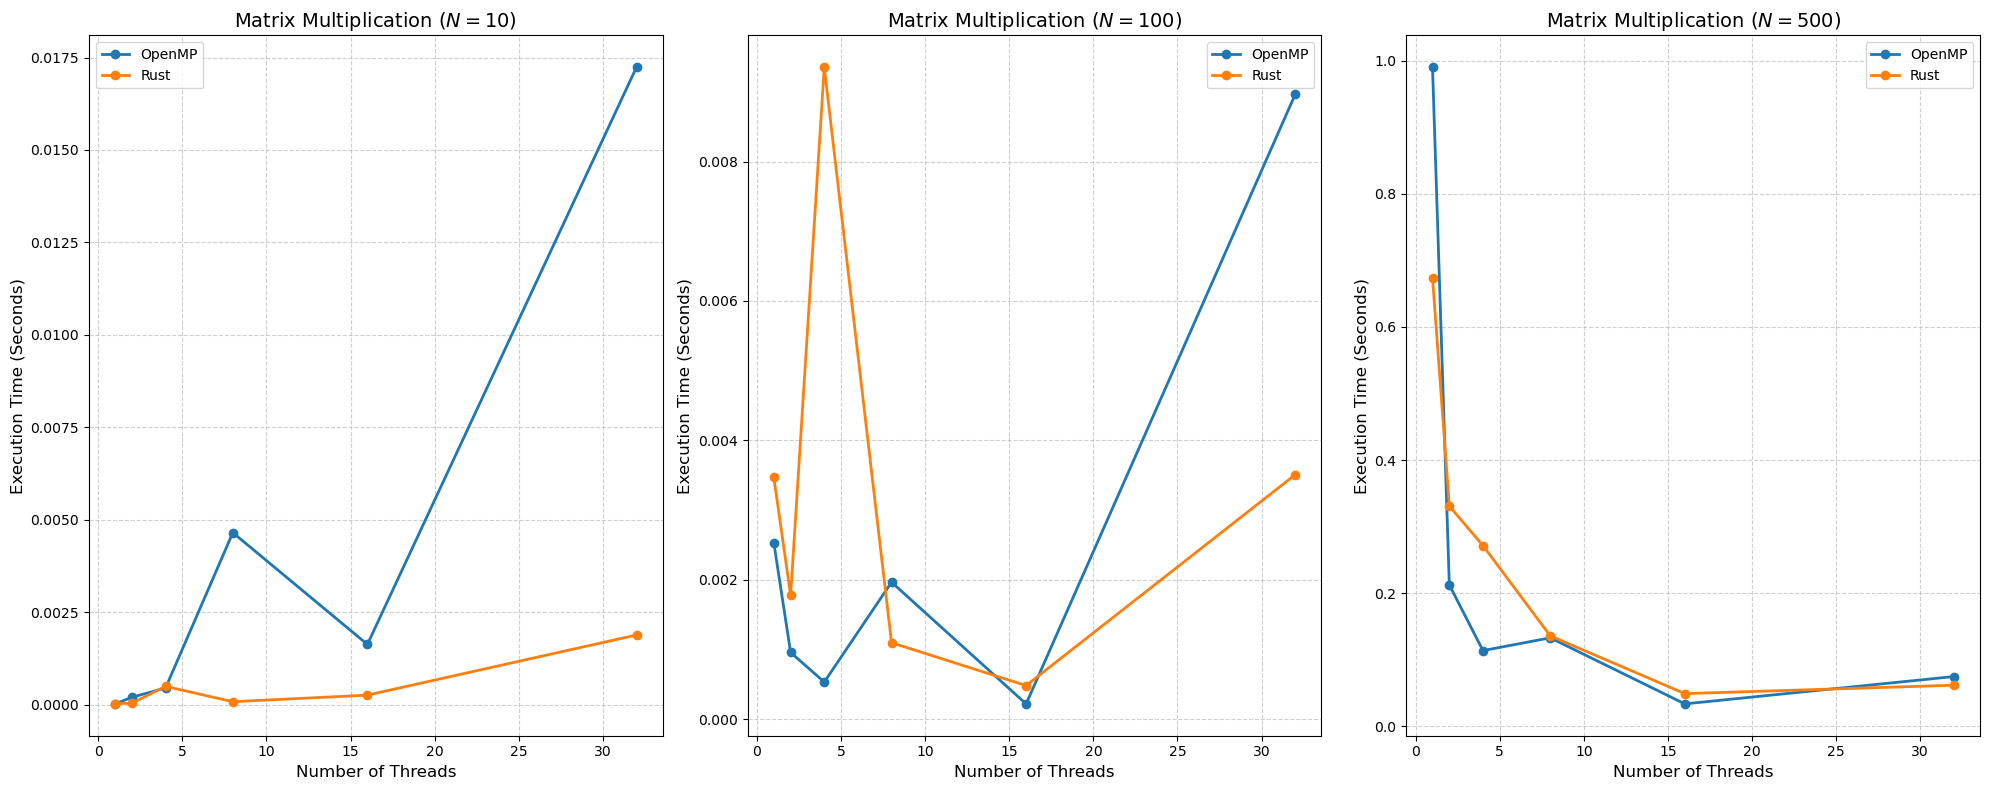

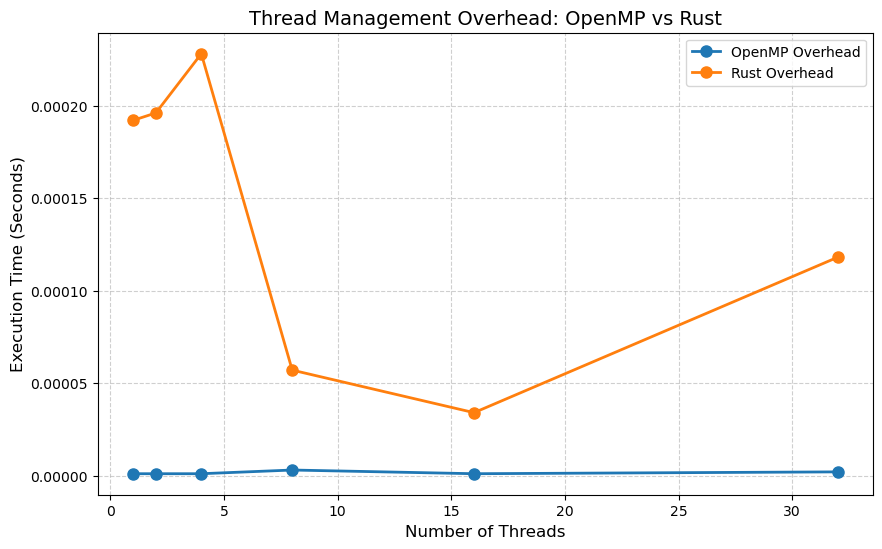

In [3]:
# Mat mul analysis
mat_mul = df[df['Benchmark'] == 'mat_mul']

n_sizes = sorted(mat_mul['Problem_Size'].unique())
fig, axes = plt.subplots(1, len(n_sizes), figsize=(20, 8))

for i, n in enumerate(n_sizes):
    ax = axes[i]
    subset_n = mat_mul[mat_mul['Problem_Size'] == n]
    
    for lang in ['OpenMP', 'Rust']:
        lang_data = subset_n[subset_n['Language'] == lang].sort_values('Threads')
        if not lang_data.empty:
            ax.plot(lang_data['Threads'], lang_data['Time_Seconds'], 
                    marker='o', label=lang, linewidth=2)
    
    ax.set_title(f'Matrix Multiplication ($N = {n}$)', fontsize=14)
    ax.set_xlabel('Number of Threads', fontsize=12)
    ax.set_ylabel('Execution Time (Seconds)', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
#plt.savefig("matmul_comp.svg", format="svg")
plt.show()


# overhead plots
overhead_data = df[df['Benchmark'] == 'overhead']
plt.figure(figsize=(10, 6))

for lang in ['OpenMP', 'Rust']:
    lang_data = overhead_data[overhead_data['Language'] == lang].sort_values('Threads')
    
    if not lang_data.empty:
        plt.plot(
            lang_data['Threads'], 
            lang_data['Time_Seconds'], 
            marker='o', 
            label=f'{lang} Overhead', 
            linewidth=2, 
            markersize=8
        )
plt.title('Thread Management Overhead: OpenMP vs Rust', fontsize=14)
plt.xlabel('Number of Threads', fontsize=12)
plt.ylabel('Execution Time (Seconds)', fontsize=12)
plt.legend()
#plt.savefig("overhead_comp.svg", format="svg")
plt.grid(True, linestyle='--', alpha=0.6)

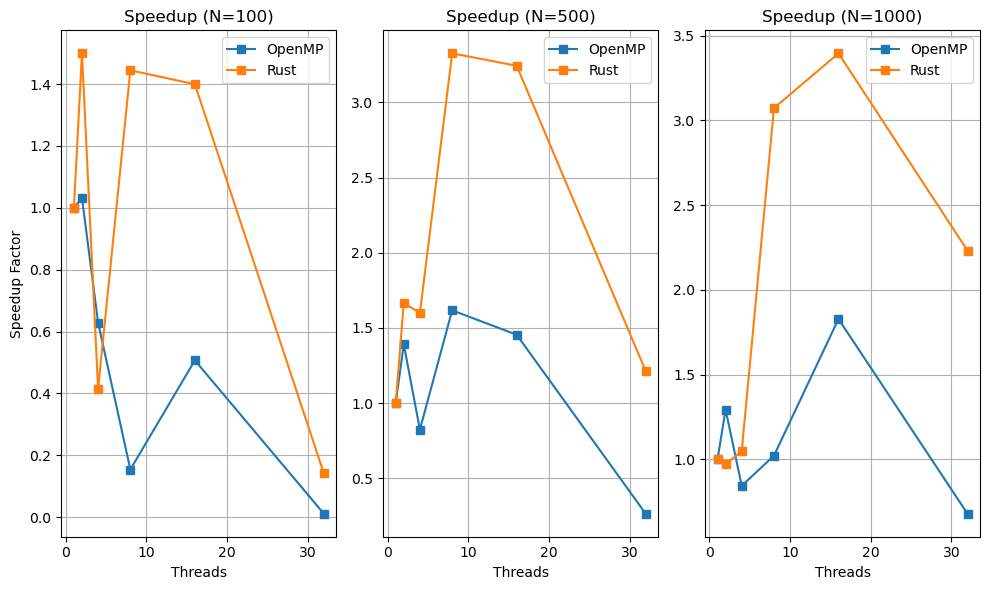

In [4]:
# Heat dist analysis
heat_data = df[df['Benchmark'] == 'heat']
sizes = heat_data['Problem_Size'].unique()

plt.figure(figsize=(10, 6))

for i, size in enumerate(sizes):
    plt.subplot(1, len(sizes), i + 1)
    for lang in ['OpenMP', 'Rust']:
        data = heat_data[(heat_data['Language'] == lang) & (heat_data['Problem_Size'] == size)]
        plt.plot(data['Threads'], data['Speedup'], marker='s', label=lang)
        
    
    plt.title(f'Speedup (N={size})')
    plt.xlabel('Threads')
    if i == 0: plt.ylabel('Speedup Factor')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
#plt.savefig("heat_comp.svg", format="svg")
plt.show()

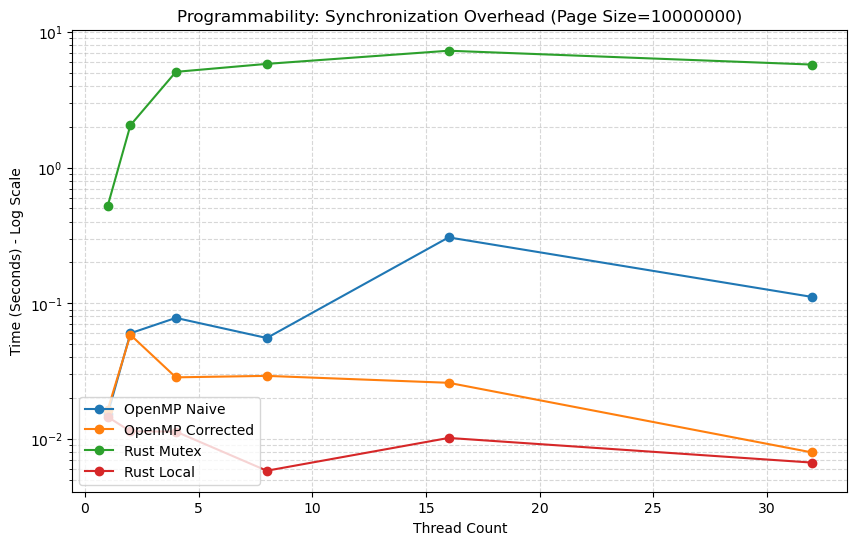

In [5]:
# histogram
hist_types = {
    'OpenMP': {'Naive': 'hist_naive', 'Corrected': 'hist_corrected'},
    'Rust': {'Mutex': 'hist_mutex', 'Local': 'hist_local'}
}

size = df[df['Benchmark'].str.contains('hist')]['Problem_Size'].max()

plt.figure(figsize=(10, 6))

for lang, types in hist_types.items():
    for label, b_name in types.items():
        data = df[(df['Benchmark'] == b_name) & (df['Threads'] > 0) & (df['Problem_Size'] == size)]
        plt.plot(data['Threads'], data['Time_Seconds'], marker='o', label=f'{lang} {label}')

plt.yscale('log')
plt.title(f'Programmability: Synchronization Overhead (Page Size={size})')
plt.xlabel('Thread Count')
plt.ylabel('Time (Seconds) - Log Scale')
plt.legend(loc="lower left")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
#plt.savefig("hist_comp.svg", format="svg")
plt.show()